# Imports


In [42]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("./") #Path.home() / "Documents" / "GitHub" / "CORI_dev"
SRC_DIR = PROJECT_DIR / "code/src"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.data import (
    TREATMENT_COLUMNS,
    cohort_audit,
    load_clinical,
    load_cohort,
    load_sites,
    load_treatment,
    merge_columns,
    collapse_cmr_columns,
    read_csv,
)
from src.models import (
    train_model,
    tune_model_cv,
    out_of_fold_score,
    score_model,
    score_values,
    predict_risk,
    save_model,
)
from src.metrics import (
    adjusted_cox,
    baseline_table,
    categorical_nri,
    c_index,
    fit_cox_columns,
    handcrafted_replication_table,
    high_low_hr,
    horizon_table,
    idi,
    likelihood_ratio_test,
    paired_delta_c,
    performance_row,
    reclassification_tables,
    residualize,
    stratified_incremental_test,
    subgroup_cox,
)
from src.matching import (
    matched_mmace_ensemble,
    information_matched_learning_curve,
    matched_curve_summary,
)
from src.plots import (
    calibration_plot,
    forest_plot,
    km_plot,
    learning_curve_plot,
    rank_transition,
    reclassification_heatmap,
)
from src.specificity import (
    dual_score_interaction_test,
    interaction_replication,
    permuted_replication_p,
    score_interaction_test,
)
from src.cmr import (
    association_table,
    domain_acat,
    domain_pc_table,
    signed_domain_association_table,
)

SEED = 20260714
np.random.seed(SEED)

# Data paths

In [43]:
DATA_DIR = PROJECT_DIR / "data"
CLEAN_DIR = DATA_DIR / "CLEAN_COHORTS_21JUL"

OUTPUT_DIR = PROJECT_DIR / "outputs_refactored"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
SCORE_DIR = OUTPUT_DIR / "scores"
QC_DIR = OUTPUT_DIR / "qc"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCORE_DIR, QC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


COHORT_FILES = {
    "D1":  "./data/CORI_input_files_21Jul/D1_CORI_cancer_development_train_ready_f1024.csv",
    "D2": "./data/CORI_input_files_21Jul/D2_CORI_cancer_heldout_train_ready_f1024.csv",
    "D3": "./data/CORI_input_files_21Jul/D3_MMACEv2_never_cancer_development_train_ready_f1024.csv",
    "D4": "./data/CORI_input_files_21Jul/D4_MMACEv2_never_cancer_heldout_train_ready_f1024.csv",
    "D6": "./data/CORI_input_files_21Jul/D6_CMR_subset_train_ready_f1024.csv",
} 

# Preserve the historical variable name so downstream cells remain unchanged.
MEANPOOL_FILES = COHORT_FILES

CLINICAL_FILE = DATA_DIR / "final_df_HTN_DB_Status.csv"
TREATMENT_FILE = DATA_DIR / "risk_score_df_final_shared_22April_2026.csv"
CANCER_SITE_FILE = DATA_DIR / "CORI_allcancer_8Jan2026.csv"
CMR_FILE = DATA_DIR / "cardiac_mri.csv"
HANDCRAFTED_FILE = DATA_DIR / "H1_handcrafted_subject_level_features_cached.csv"

DEEP_FEATURES = [f"f{i}" for i in range(1024)]
FEATURE_VIEW_COLUMN = "feature_prefix_used"
FEATURE_SOURCE_COLUMN = "source_name"

CLINICAL_VARIABLES = ["age", "female", "height", "Diabetes", "HTN"]
PRIMARY_ADJUSTMENT = ["age", "female", "Diabetes", "HTN"]
MATCH_VARIABLES = ["age", "female", "height"]
CANCER_SITE_COLUMNS = [
    "DigestiveCancer_present", "RespiCancer_present", "BreastCancer_present",
    "FemRepoCancer_present", "MaleRepoCancer_present", "UrinaryTractCancer_present",
    "EndocrineCancer_present", "HeamatoCancer_present", "InsituCancer_present",
    "LipOralCancer_present", "BoneCancer_present", "SkinCancer_present",
    "MesotheliumCancer_present", "EyeCNSCancer_present", "SecondaryCancer_present",
    "UnknownCancer_present",
]


TUNING_K = [10, 15, 20]
TUNING_PENALTIES = [0.001, 0.01, 0.05, 0.1]
TUNING_FOLDS = 3
TUNING_REPEATS = 3
TUNING_RULE = "one_se"

BOOTSTRAPS = 1000
MATCHED_REPETITIONS = 200
CRUDE_MATCHED_REPETITIONS = 200

RUN_FULL_LEARNING_CURVE = True
RUN_ALL_REPRESENTATIONS = False
RUN_HANDCRAFTED = True
RUN_CMR = True
RUN_CROSSFIT_MEDIATION = True

# Records the explicit decision to retain both pre-existing
# RETFound-derived feature provenance groups in the train-ready cohorts.
ALLOW_MIXED_RETFOUND_VIEWS = True


In [44]:
def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path)
    return df


def add_groups(df, score_column, thresholds, prefix):
    out = df.copy()
    out[f"{prefix}_high"] = (out[score_column] > thresholds["median"]).astype(int)
    out[f"{prefix}_tertile"] = pd.cut(
        out[score_column],
        [-np.inf, thresholds["tertile_1"], thresholds["tertile_2"], np.inf],
        labels=["Low", "Middle", "High"],
        include_lowest=True,
    ).astype(str)
    return out


def score_thresholds(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.quantile(values, 0.50)),
        "tertile_1": float(np.quantile(values, 1 / 3)),
        "tertile_2": float(np.quantile(values, 2 / 3)),
    }


# Load data

In [45]:
# ============================================================
# Load train-ready RETFound-derived cohorts
# ============================================================

meanpool = {
    cohort: load_cohort(COHORT_FILES[cohort], DEEP_FEATURES)
    for cohort in COHORT_FILES.keys()
}

# Harmonize the authoritative cancer indicator and retain provenance.
for cohort, cohort_df in meanpool.items():
    if "A_cancer_primary" in cohort_df.columns:
        cohort_df["A_cancer"] = pd.to_numeric(
            cohort_df["A_cancer_primary"],
            errors="raise",
        ).astype(int)

    if FEATURE_VIEW_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_VIEW_COLUMN] = "unknown"

    if FEATURE_SOURCE_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_SOURCE_COLUMN] = "unknown"

    cohort_df[FEATURE_VIEW_COLUMN] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )
    cohort_df[FEATURE_SOURCE_COLUMN] = (
        cohort_df[FEATURE_SOURCE_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )

    # Retained for optional provenance-adjusted sensitivity analyses.
    cohort_df["feature_view_emb2"] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .eq("emb2_f")
        .astype(int)
    )


# ============================================================
# Merge approved external metadata exactly as before
# ============================================================

clinical = load_clinical(CLINICAL_FILE)
treatment = load_treatment(TREATMENT_FILE)
sites = load_sites(CANCER_SITE_FILE, CANCER_SITE_COLUMNS)

for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], clinical)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], treatment)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], sites)

meanpool["D1"]["split"] = "Development"
meanpool["D2"]["split"] = "Held-out"
meanpool["D3"]["split"] = "Development"
meanpool["D4"]["split"] = "Held-out"


In [46]:
cancer_all = pd.concat([meanpool["D1"], meanpool["D2"]], ignore_index=True)
table_1 = baseline_table(
    cancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")


time_col = "time_years"
event_col = "Y_mace"

display(cancer_all[time_col].describe())
display(cancer_all[event_col].describe())

Noncancer_all = pd.concat([meanpool["D3"], meanpool["D4"]], ignore_index=True)
table_1 = baseline_table(
    Noncancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")

display(Noncancer_all[time_col].describe())
display(Noncancer_all[event_col].describe())

,variable,Overall,Development,Held-out
0,age,57.6 (7.7),57.4 (7.8),57.8 (7.7)
1,height,166.9 (8.8),166.6 (8.7),167.2 (8.8)
2,female,"3,164 (68.9%)","1,523 (70.6%)","1,641 (67.4%)"
3,Diabetes,214 (4.7%),102 (4.7%),112 (4.6%)
4,HTN,"1,221 (26.6%)",595 (27.6%),626 (25.7%)
5,Y_mace,635 (13.8%),300 (13.9%),335 (13.8%)


count    4591.000000
mean        9.107704
std         2.215997
min         0.008214
25%         9.993155
50%         9.993155
75%         9.993155
max         9.998631
Name: time_years, dtype: float64

count    4591.000000
mean        0.138314
std         0.345267
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Y_mace, dtype: float64

,variable,Overall,Development,Held-out
0,age,54.8 (8.2),54.6 (8.2),54.9 (8.2)
1,height,168.9 (9.3),168.7 (9.3),169.1 (9.2)
2,female,"15,983 (55.3%)","7,913 (55.9%)","8,070 (54.7%)"
3,Diabetes,"1,068 (3.7%)",544 (3.8%),524 (3.5%)
4,HTN,"6,248 (21.6%)","3,093 (21.8%)","3,155 (21.4%)"
5,Y_mace,"2,809 (9.7%)","1,348 (9.5%)","1,461 (9.9%)"


count    28922.000000
mean         9.588569
std          1.532134
min          0.008214
25%          9.998631
50%          9.998631
75%          9.998631
max          9.998631
Name: time_years, dtype: float64

count    28922.000000
mean         0.097123
std          0.296131
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Y_mace, dtype: float64

In [47]:

def preprocess_features(train_df, test_df, test2_df, test3_df, candidate, var_threshold=0.01, corr_threshold=0.9, verbose=True):
    for col in candidate:
        p1 = train_df[col].quantile(0.01)
        p99 = train_df[col].quantile(0.99)
        train_df[col] = train_df[col].clip(p1, p99)
        test_df[col] = test_df[col].clip(p1, p99)
        test2_df[col] = test2_df[col].clip(p1, p99)
        test3_df[col] = test3_df[col].clip(p1, p99)

    mean_vals = train_df[candidate].mean()
    std_vals = train_df[candidate].std()

    train_df[candidate] = (train_df[candidate] - mean_vals) / std_vals
    test_df[candidate] = (test_df[candidate] - mean_vals) / std_vals
    test2_df[candidate] = (test2_df[candidate] - mean_vals) / std_vals
    test3_df[candidate] = (test3_df[candidate] - mean_vals) / std_vals
    
    var = train_df[candidate].var()
    candidate = var[var > var_threshold].index.tolist()

    if verbose:
        print("After variance filtering:", len(candidate))

    corr = train_df[candidate].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
    candidate = [c for c in candidate if c not in to_drop]

    if verbose:
        print("After correlation filtering:", len(candidate))

    return train_df, test_df, test2_df, test3_df, candidate, mean_vals, std_vals

d1_coriPreProcess , d2_coriPreProcess , d3_coriPreProcess ,d4_coriPreProcess , Cori_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D1"], meanpool["D2"], meanpool["D3"], meanpool["D4"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)

d3_MMACEPreProcess , d4_MMACEPreProcess , d1_MMACEPreProcess , d2_MMACEPreProcess , MMACE_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D3"], meanpool["D4"], meanpool["D1"], meanpool["D2"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)



After variance filtering: 1024
After correlation filtering: 946
After variance filtering: 1024
After correlation filtering: 149


In [48]:
# cori_cohort_dict = {
#     "D1": d1_coriPreProcess,
#     "D2": d2_coriPreProcess,
#     "D4": d4_coriPreProcess,
# }

# mmace_cohort_dict = {
#     "D3": d3_MMACEPreProcess,
#     "D4": d4_MMACEPreProcess,
#     "D2": d2_MMACEPreProcess,
# }

meanpool['D1_cori'] = d1_coriPreProcess
meanpool['D2_cori'] = d2_coriPreProcess
meanpool['D3_cori'] = d3_coriPreProcess
meanpool['D4_cori'] = d4_coriPreProcess

meanpool['D1_mmace'] = d1_MMACEPreProcess
meanpool['D2_mmace'] = d2_MMACEPreProcess
meanpool['D3_mmace'] = d3_MMACEPreProcess
meanpool['D4_mmace'] = d4_MMACEPreProcess

# Disentanglement learning

In [49]:
train_X = pd.concat([d1_coriPreProcess[['eid'] + DEEP_FEATURES],
                     d3_coriPreProcess [['eid'] + DEEP_FEATURES]], 
                    ignore_index=True).to_numpy()
train_Y1 = [1] * len(d1_coriPreProcess) + [0] * len(d3_coriPreProcess)
train_Y2 = d1_coriPreProcess['Y_mace'].tolist() + d3_coriPreProcess['Y_mace'].tolist()

train_df = pd.DataFrame(train_X)
train_df['Y_cancer'] = train_Y1
train_df['Y_mace'] = train_Y2


test_X = pd.concat([d2_coriPreProcess[['eid'] + DEEP_FEATURES],
                    d4_coriPreProcess [['eid'] + DEEP_FEATURES]], 
                   ignore_index=True).to_numpy()
test_Y1 = [1] * len(d2_coriPreProcess) + [0] * len(d4_coriPreProcess)
test_Y2 = d2_coriPreProcess['Y_mace'].tolist() + d4_coriPreProcess['Y_mace'].tolist()

test_df = pd.DataFrame(test_X)
test_df['Y_cancer'] = test_Y1
test_df['Y_mace'] = test_Y2


In [50]:
d1_coriPreProcess

,eid,A_cancer,Y_mace,time_years,age,female,height,center,analysis_role,scan_date_img,...,HeamatoCancer_present,InsituCancer_present,LipOralCancer_present,BoneCancer_present,SkinCancer_present,MesotheliumCancer_present,EyeCNSCancer_present,SecondaryCancer_present,UnknownCancer_present,split
0,1000482,1,0,9.993155,41.0,1.0,166.0,Birmingham,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
1,1000701,1,0,9.993155,49.0,1.0,171.5,Birmingham,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
2,1005922,1,0,9.993155,55.0,0.0,166.0,Croydon,Development,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,Development
3,1007213,1,0,9.993155,56.0,1.0,172.0,Birmingham,Development,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
4,1007738,1,0,9.993155,54.0,1.0,165.0,Croydon,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2151,6016693,1,0,9.993155,44.0,1.0,164.7,Croydon,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
2152,6017493,1,0,9.993155,47.0,0.0,170.0,Birmingham,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
2153,6018198,1,0,9.993155,59.0,1.0,159.0,Croydon,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development
2154,6020228,1,1,7.501711,61.0,0.0,169.0,Birmingham,Development,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Development


In [52]:
cancer_col = [x for x in d1_coriPreProcess.columns if "Cancer_present" in x]
cancer_col

['DigestiveCancer_present',
 'RespiCancer_present',
 'BreastCancer_present',
 'FemRepoCancer_present',
 'MaleRepoCancer_present',
 'UrinaryTractCancer_present',
 'EndocrineCancer_present',
 'HeamatoCancer_present',
 'InsituCancer_present',
 'LipOralCancer_present',
 'BoneCancer_present',
 'SkinCancer_present',
 'MesotheliumCancer_present',
 'EyeCNSCancer_present',
 'SecondaryCancer_present',
 'UnknownCancer_present']

In [ ]:
# find features that are cancer-specific

for feats in DEE

# Hparam selection

## CORI hparam

In [53]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from scipy.stats import norm
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from lifelines.utils import concordance_index

from src.models import rank_features , rank_features2

In [55]:


from src.models import _cv_strata_labels
from src.models import *

def tune_model_cv(
    train_df: pd.DataFrame,
    feature_columns: list[str],
    name: str,
    candidate_k: list[int],
    candidate_penalizers: list[float],
    folds: int = 3,
    repeats: int = 3,
    seed: int = 20260714,
    rule: str = "one_se",
) -> tuple[LockedCoxModel, pd.DataFrame, dict]:
    """
    Tune model complexity using development-only repeated CV.

    Feature ranking is recomputed inside each training fold. CORI and MMACE
    should receive the same candidate grid, number of folds, and repeats.
    """
    labels = _cv_strata_labels(train_df, folds=folds)
    splitter = RepeatedStratifiedKFold(
        n_splits=folds,
        n_repeats=repeats,
        random_state=seed,
    )

    rows: list[dict] = []
    dummy = np.zeros(len(train_df), dtype=int)

    for split, (train_index, valid_index) in enumerate(
        splitter.split(dummy, labels)
    ):
        development = train_df.iloc[train_index].copy()
        validation = train_df.iloc[valid_index].copy()
        # ranking = rank_features(development, feature_columns, penalizer=0.01)
        ranking = rank_features2(development, feature_columns, penalizer=0.01)
        

        for n_features in candidate_k:
            if n_features > len(ranking):
                continue
            for penalizer in candidate_penalizers:
                
                # top features
                top_ranked_features = ranking.head(n_features)["feature"].tolist()
                
                model = fit_model_from_ranking(
                    development,
                    ranking,
                    name=f"{name}_cv",
                    n_features=n_features,
                    penalizer=penalizer,
                )
                values = score_values(model, validation)
                c_value = concordance_index(
                    pd.to_numeric(validation["time_years"], errors="raise"),
                    -values,
                    pd.to_numeric(validation["Y_mace"], errors="raise"),
                )
                temp_row= {
                        "split": split,
                        "n_features": int(n_features),
                        "penalizer": float(penalizer),
                        "C_index": float(c_value),
                        "top_features": top_ranked_features,
                    }
                rows.append(temp_row)
                print(temp_row)

    if not rows:
        raise RuntimeError("No valid hyperparameter configuration was evaluated.")

    summary = (
        pd.DataFrame(rows)
        .groupby(["n_features", "penalizer"], as_index=False)
        .agg(
            mean_C=("C_index", "mean"),
            sd_C=("C_index", "std"),
            n=("C_index", "size"),
        )
    )
    summary["sd_C"] = summary["sd_C"].fillna(0.0)
    summary["se_C"] = summary["sd_C"] / np.sqrt(summary["n"])

    best = summary.loc[summary["mean_C"].idxmax()].copy()

    if rule == "max":
        chosen = best
    elif rule == "one_se":
        eligible = summary.loc[
            summary["mean_C"] >= best["mean_C"] - best["se_C"]
        ].copy()
        chosen = eligible.sort_values(
            ["n_features", "penalizer"],
            ascending=[True, False],
        ).iloc[0]
    else:
        raise ValueError("rule must be either 'max' or 'one_se'.")

    final_model = train_model(
        train_df,
        feature_columns,
        name=name,
        n_features=int(chosen["n_features"]),
        penalizer=float(chosen["penalizer"]),
    )
    choice = {
        "rule": rule,
        "n_features": int(chosen["n_features"]),
        "penalizer": float(chosen["penalizer"]),
        "mean_internal_C": float(chosen["mean_C"]),
        "best_internal_C": float(best["mean_C"]),
        "cv_splits": int(folds * repeats),
    }
    return final_model, summary, choice

In [56]:

overlap_feats = {'f370', 'f501', 'f355', 'f940', 'f323', 'f657', 'f51', 'f74', 'f620', 'f811', 'f509', 'f6', 'f242', 'f275', 'f689', 'f832', 'f762', 'f438', 'f737', 'f424', 'f792', 'f867', 'f183', 'f18'}
cancerOnly_feats = {'f513', 'f771', 'f507', 'f250', 'f443', 'f666', 'f976', 'f339', 'f95', 'f240', 'f721', 'f836', 'f907', 'f385', 'f727', 'f537', 'f686', 'f604', 'f731', 'f866', 'f497', 'f729', 'f944', 'f110', 'f459', 'f350', 'f89', 'f584', 'f22', 'f704', 'f534', 'f347', 'f775', 'f523', 'f955', 'f263', 'f340', 'f10', 'f177', 'f137', 'f557', 'f542', 'f72', 'f431', 'f284', 'f699', 'f121', 'f1011', 'f578', 'f34', 'f113', 'f441', 'f194', 'f682'}
maceOnly_feats = {'f603', 'f405', 'f717', 'f80', 'f217', 'f1021', 'f471', 'f156', 'f477', 'f328', 'f176', 'f521', 'f354', 'f260', 'f196', 'f986', 'f935', 'f185', 'f369', 'f322', 'f546', 'f767', 'f693', 'f440', 'f586', 'f427', 'f644', 'f416', 'f869', 'f552', 'f941', 'f927', 'f873', 'f247', 'f587', 'f989', 'f967', 'f5', 'f561', 'f79', 'f556', 'f725', 'f826', 'f188', 'f285', 'f929', 'f12', 'f909', 'f565', 'f338', 'f518', 'f994'}


# Equal search opportunity: same grid, folds, repeats, and one-SE rule.
cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
    meanpool["D1_cori"],
    cancerOnly_feats,
    name="CORI_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

{'split': 0, 'n_features': 10, 'penalizer': 0.001, 'C_index': 0.49616031087603507, 'top_features': ['f666', 'f441', 'f110', 'f22', 'f686', 'f121', 'f976', 'f604', 'f584', 'f775']}
{'split': 0, 'n_features': 10, 'penalizer': 0.01, 'C_index': 0.4942481765331771, 'top_features': ['f666', 'f441', 'f110', 'f22', 'f686', 'f121', 'f976', 'f604', 'f584', 'f775']}
{'split': 0, 'n_features': 10, 'penalizer': 0.05, 'C_index': 0.4880645807953862, 'top_features': ['f666', 'f441', 'f110', 'f22', 'f686', 'f121', 'f976', 'f604', 'f584', 'f775']}
{'split': 0, 'n_features': 10, 'penalizer': 0.1, 'C_index': 0.4813721105953831, 'top_features': ['f666', 'f441', 'f110', 'f22', 'f686', 'f121', 'f976', 'f604', 'f584', 'f775']}
{'split': 0, 'n_features': 15, 'penalizer': 0.001, 'C_index': 0.5120742031488534, 'top_features': ['f666', 'f441', 'f110', 'f22', 'f686', 'f121', 'f976', 'f604', 'f584', 'f775', 'f699', 'f729', 'f907', 'f682', 'f385']}
{'split': 0, 'n_features': 15, 'penalizer': 0.01, 'C_index': 0.51002

In [57]:
cori_tuned_model.feature_columns

['f666',
 'f441',
 'f350',
 'f89',
 'f121',
 'f22',
 'f907',
 'f557',
 'f1011',
 'f507',
 'f944',
 'f731',
 'f976',
 'f721',
 'f537']

In [58]:
cori_tuning_choice

{'rule': 'one_se',
 'n_features': 15,
 'penalizer': 0.05,
 'mean_internal_C': 0.5448454992018867,
 'best_internal_C': 0.5496151454297833,
 'cv_splits': 9}

In [59]:
cori_tuning['sd_c_neg'] = cori_tuning['sd_C'].round(3) * -1
cori_tuning['mean_C_round'] = cori_tuning['mean_C'].round(3)

cori_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
4,15,0.001,0.549615,0.022702,9,0.007567,-0.023,0.550
5,15,0.010,0.549090,0.022421,9,0.007474,-0.022,0.549
6,15,0.050,0.544845,0.022780,9,0.007593,-0.023,0.545
8,20,0.001,0.545461,0.024925,9,0.008308,-0.025,0.545
9,20,0.010,0.545493,0.024724,9,0.008241,-0.025,0.545
10,20,0.050,0.541812,0.023795,9,0.007932,-0.024,0.542
7,15,0.100,0.539923,0.023411,9,0.007804,-0.023,0.540
0,10,0.001,0.539379,0.021995,9,0.007332,-0.022,0.539
1,10,0.010,0.539241,0.022036,9,0.007345,-0.022,0.539
11,20,0.100,0.537731,0.023250,9,0.007750,-0.023,0.538


## MMACE hparam

In [60]:

mmace_tuned_model, mmace_tuning, mmace_tuning_choice = tune_model_cv(
    meanpool["D3_mmace"],
    maceOnly_feats,
    name="MMACE_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)



{'split': 0, 'n_features': 10, 'penalizer': 0.001, 'C_index': 0.5941034500015112, 'top_features': ['f80', 'f260', 'f440', 'f989', 'f12', 'f546', 'f561', 'f929', 'f338', 'f994']}
{'split': 0, 'n_features': 10, 'penalizer': 0.01, 'C_index': 0.5939944436489183, 'top_features': ['f80', 'f260', 'f440', 'f989', 'f12', 'f546', 'f561', 'f929', 'f338', 'f994']}
{'split': 0, 'n_features': 10, 'penalizer': 0.05, 'C_index': 0.5932898662244313, 'top_features': ['f80', 'f260', 'f440', 'f989', 'f12', 'f546', 'f561', 'f929', 'f338', 'f994']}
{'split': 0, 'n_features': 10, 'penalizer': 0.1, 'C_index': 0.592779022817507, 'top_features': ['f80', 'f260', 'f440', 'f989', 'f12', 'f546', 'f561', 'f929', 'f338', 'f994']}
{'split': 0, 'n_features': 15, 'penalizer': 0.001, 'C_index': 0.5910151018391849, 'top_features': ['f80', 'f260', 'f440', 'f989', 'f12', 'f546', 'f561', 'f929', 'f338', 'f994', 'f603', 'f471', 'f217', 'f185', 'f935']}
{'split': 0, 'n_features': 15, 'penalizer': 0.01, 'C_index': 0.591991204178

In [61]:
mmace_tuned_model.feature_columns

['f260', 'f80', 'f929', 'f12', 'f440', 'f546', 'f989', 'f561', 'f338', 'f994']

In [62]:
mmace_tuning_choice

{'rule': 'one_se',
 'n_features': 10,
 'penalizer': 0.1,
 'mean_internal_C': 0.5984859736511161,
 'best_internal_C': 0.6022157917148026,
 'cv_splits': 9}

In [64]:
mmace_tuning['sd_c_neg'] = mmace_tuning['sd_C'].round(3) * -1
mmace_tuning['mean_C_round'] = mmace_tuning['mean_C'].round(3)

mmace_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
5,15,0.010,0.602048,0.013985,9,0.004662,-0.014,0.602
4,15,0.001,0.601926,0.014762,9,0.004921,-0.015,0.602
9,20,0.010,0.602216,0.014744,9,0.004915,-0.015,0.602
6,15,0.050,0.600801,0.012917,9,0.004306,-0.013,0.601
10,20,0.050,0.600788,0.012661,9,0.004220,-0.013,0.601
8,20,0.001,0.601264,0.015400,9,0.005133,-0.015,0.601
0,10,0.001,0.600507,0.015743,9,0.005248,-0.016,0.601
11,20,0.100,0.599823,0.011414,9,0.003805,-0.011,0.600
7,15,0.100,0.600068,0.011968,9,0.003989,-0.012,0.600
1,10,0.010,0.600053,0.015617,9,0.005206,-0.016,0.600


In [65]:
from src2.train import train_cox_model


# cori_features = ['f98', 'f260', 'f989', 'f728', 'f319', 'f80', 'f440', 'f735', 'f689', 'f119'] 
# mmace_features = ['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']

cori_features = cori_tuned_model.feature_columns
mmace_features = mmace_tuned_model.feature_columns

print(cori_features)
print(mmace_features)

['f666', 'f441', 'f350', 'f89', 'f121', 'f22', 'f907', 'f557', 'f1011', 'f507', 'f944', 'f731', 'f976', 'f721', 'f537']
['f260', 'f80', 'f929', 'f12', 'f440', 'f546', 'f989', 'f561', 'f338', 'f994']


In [66]:



print(cori_features)
print(mmace_features)

['f666', 'f441', 'f350', 'f89', 'f121', 'f22', 'f907', 'f557', 'f1011', 'f507', 'f944', 'f731', 'f976', 'f721', 'f537']
['f260', 'f80', 'f929', 'f12', 'f440', 'f546', 'f989', 'f561', 'f338', 'f994']


# Train model

## Test CORI on D2

In [67]:
# for cohort in ["D1", "D2", "D3", "D4"]:
#     print(f"cohort: {cohort}")
#     try:
#         display(cori_cohort_dict[cohort][cori_features  + [time_col, event_col]].describe().round(4))
#     except Exception as e:
#         print(f"Error displaying cohort {cohort}: {e}")

 train shape: (2156, 1089)
 test shape: (2435, 1089)


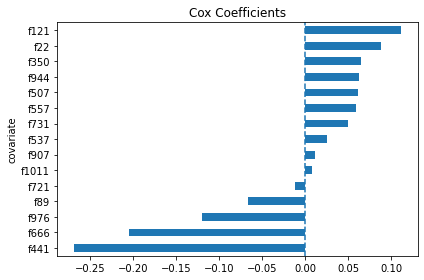

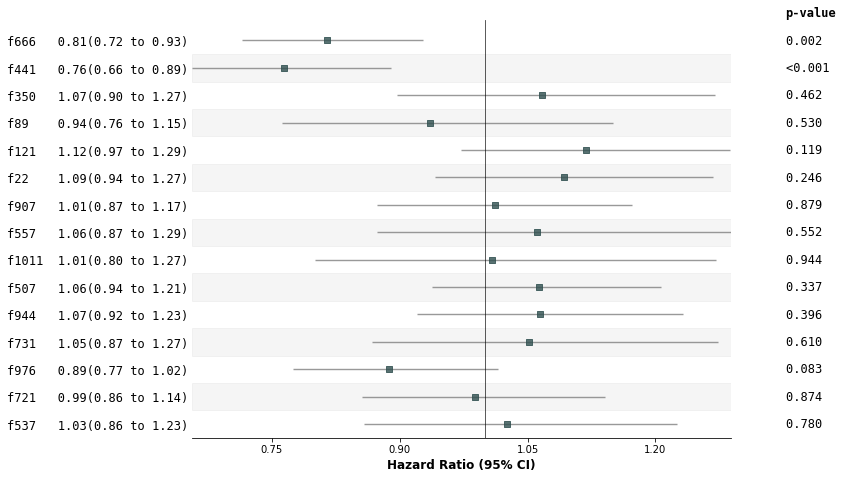

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.349 (95% CI 1.015 - 1.792), p = 0.0392
  G3 vs G1: HR = 1.965 (95% CI 1.503 - 2.570), p = 7.77e-07

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.530 (95% CI 1.186 - 1.973), p = 0.00108
  G3 vs G1: HR = 1.667 (95% CI 1.298 - 2.142), p = 6.32e-05


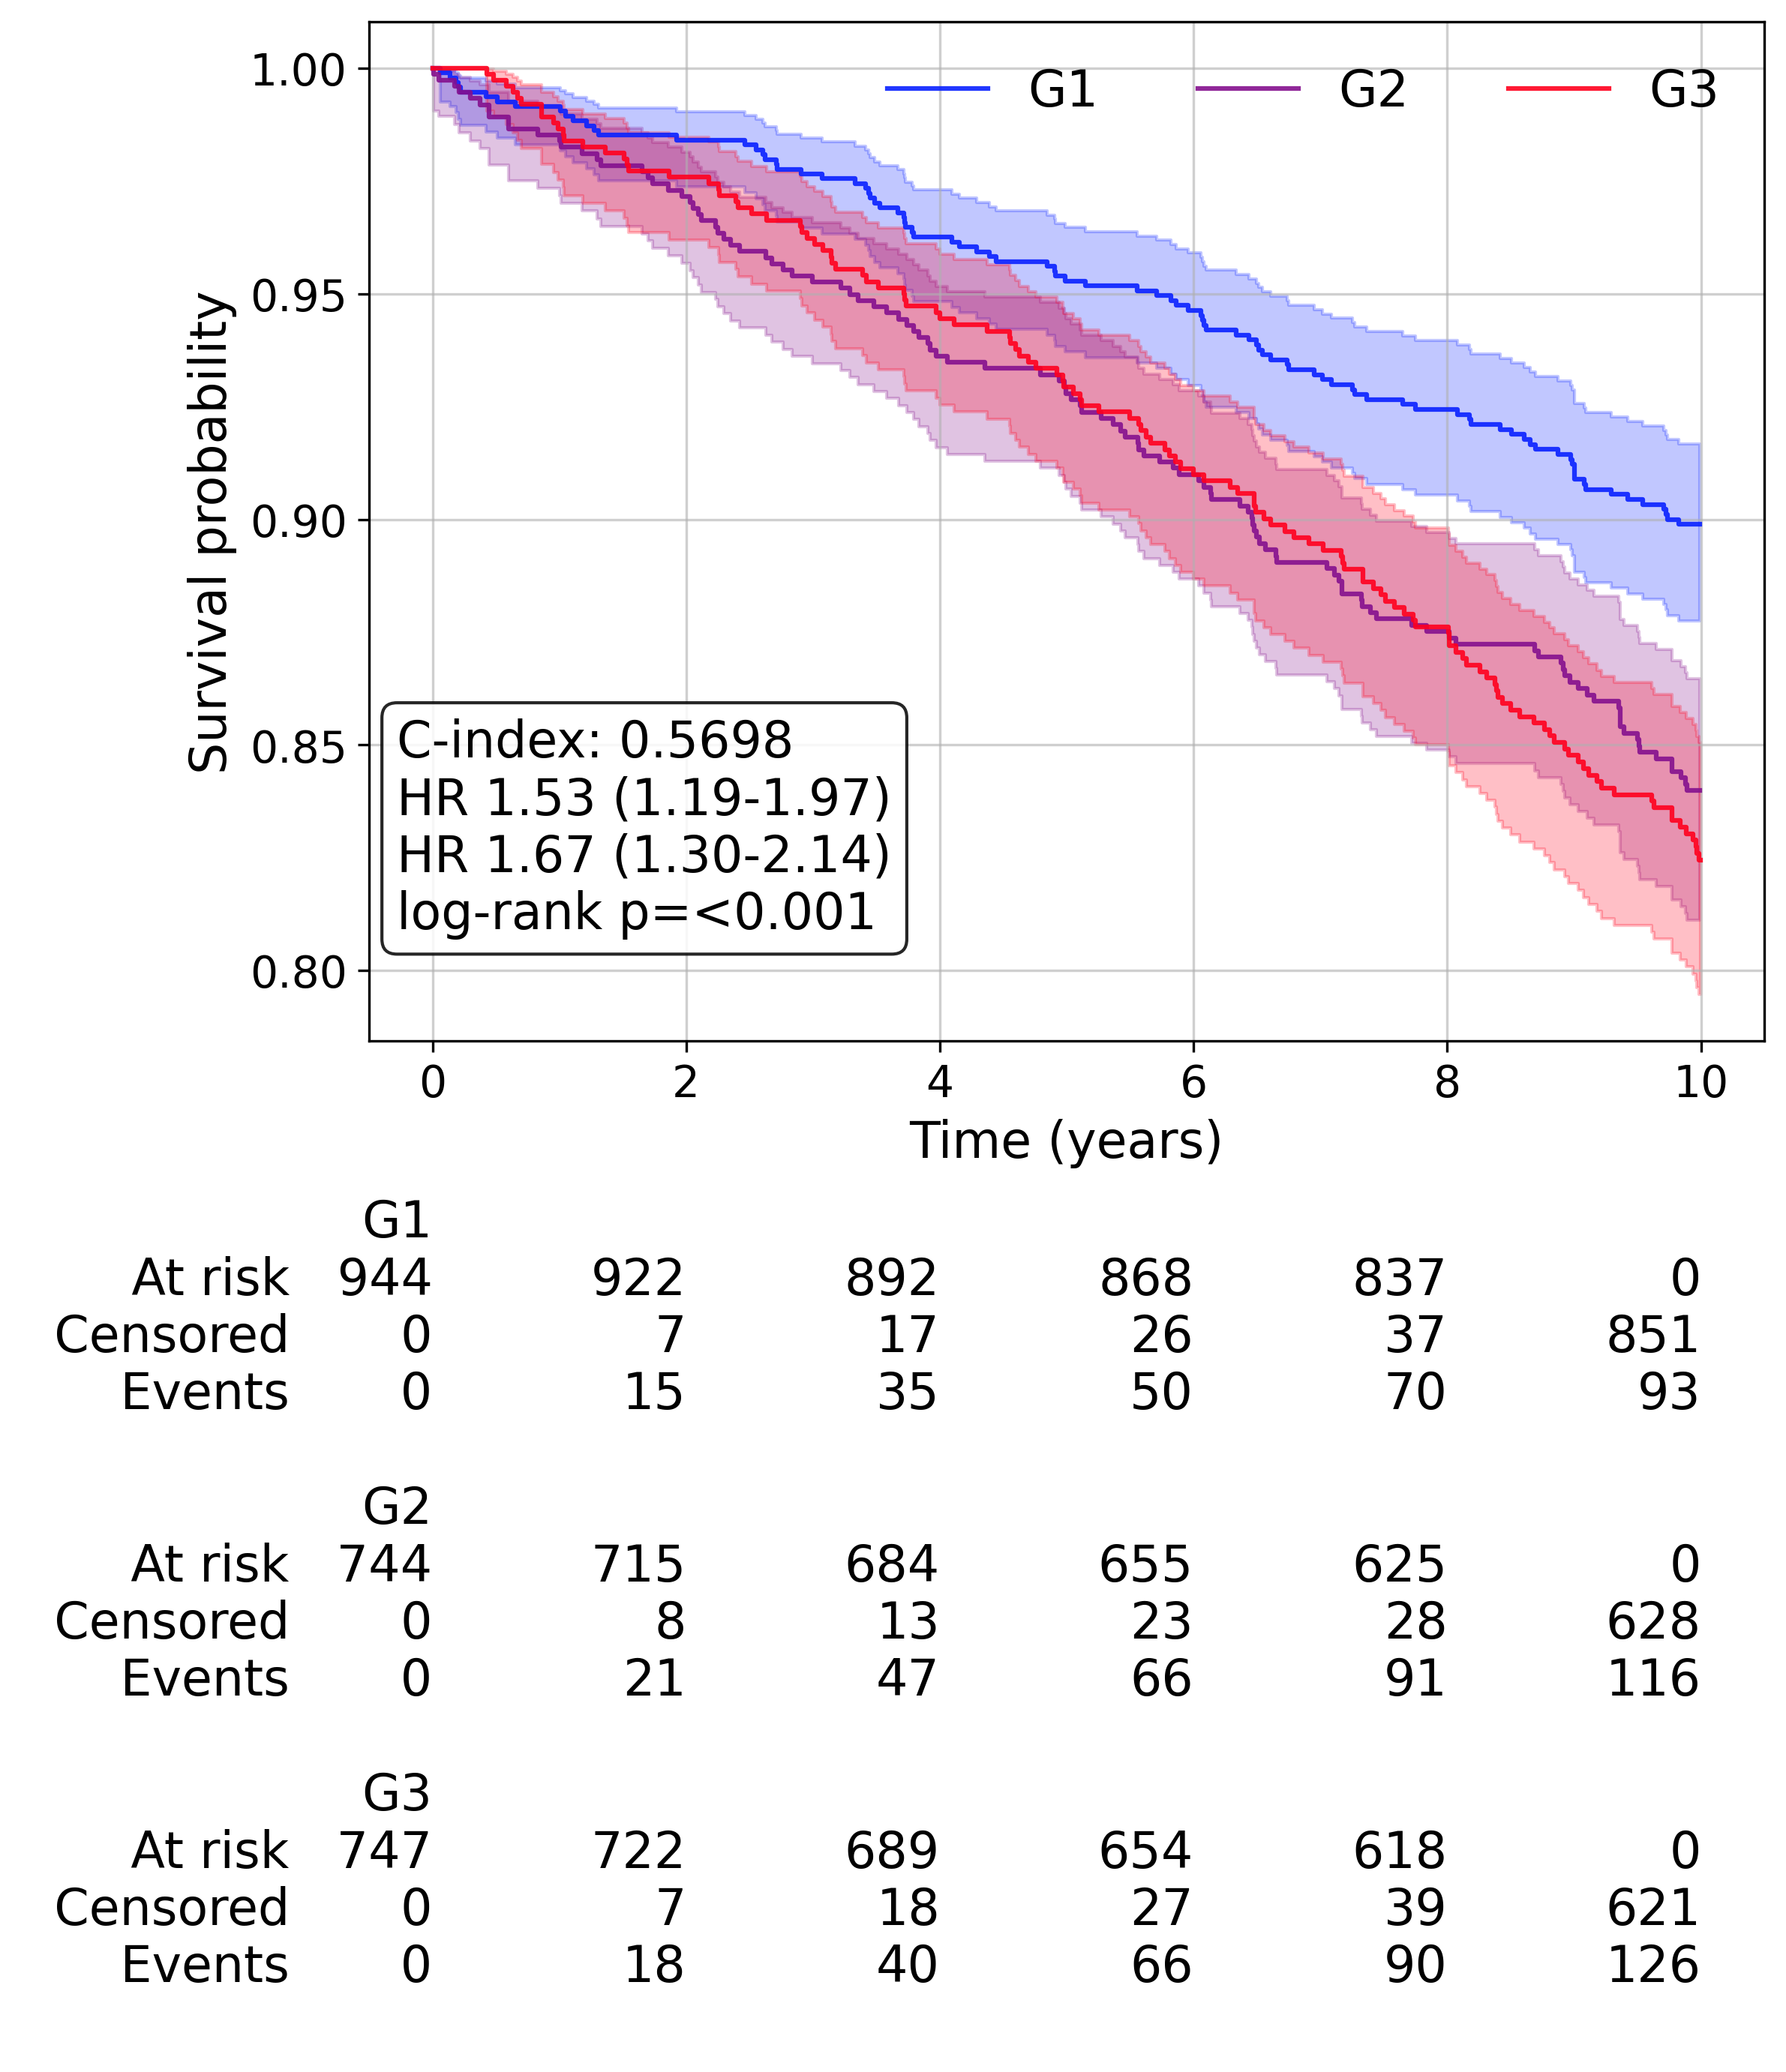

In [68]:
outputs = train_cox_model(train_df = meanpool["D1_cori"],
    test_df = meanpool["D2_cori"],
    selected_features = cori_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test MMACE on D4

 train shape: (14159, 1069)
 test shape: (14763, 1069)


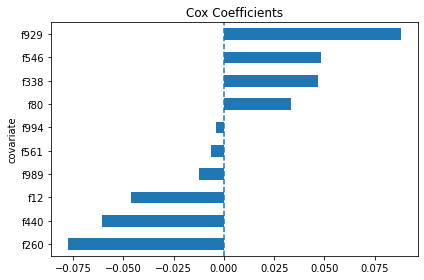

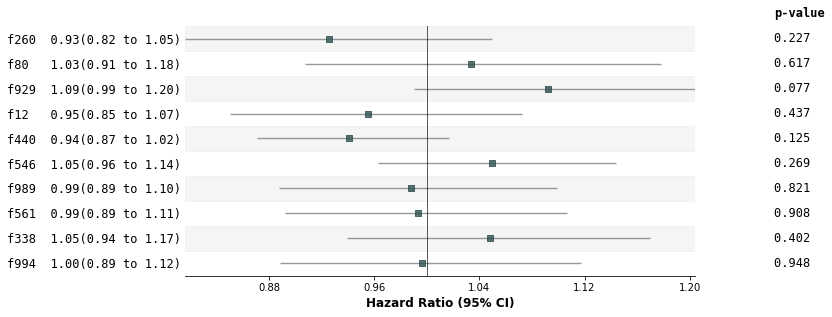

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 0.999 (95% CI 0.875 - 1.141), p = 0.991
  G3 vs G1: HR = 1.790 (95% CI 1.590 - 2.016), p = 7.87e-22

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.105 (95% CI 0.971 - 1.257), p = 0.129
  G3 vs G1: HR = 1.798 (95% CI 1.601 - 2.020), p = 3.79e-23


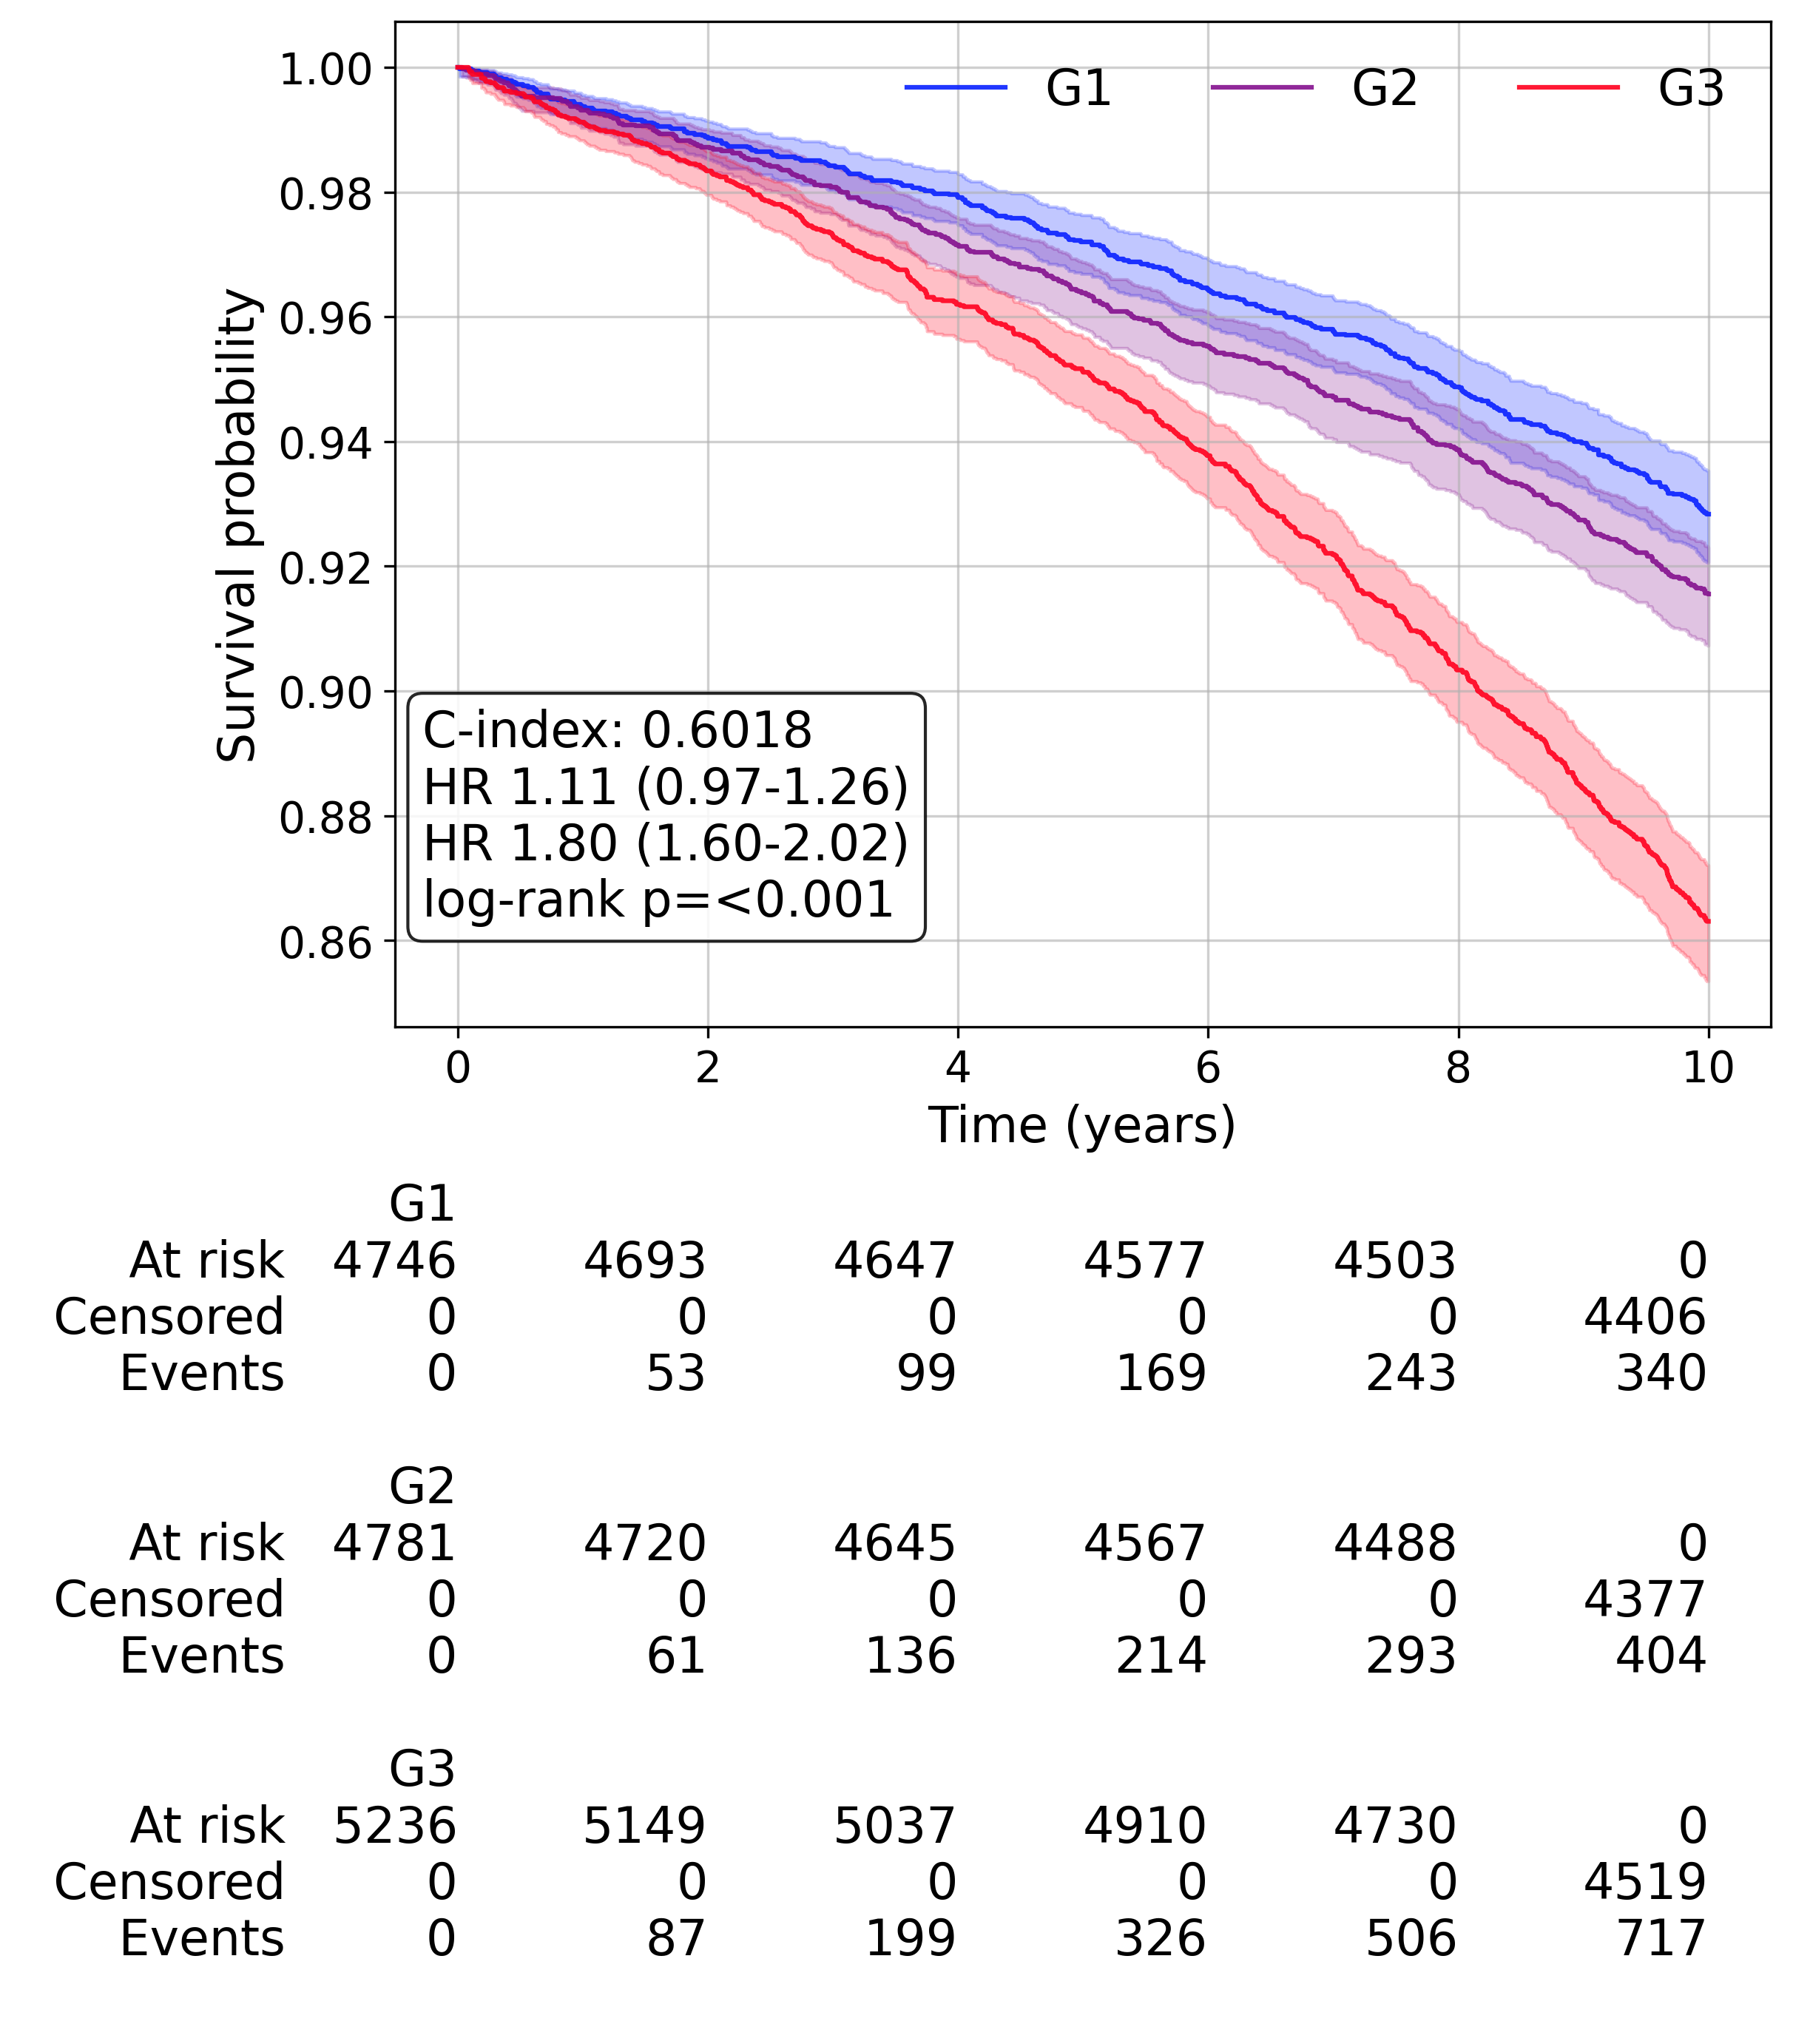

In [69]:


outputs = train_cox_model(train_df = meanpool["D3_mmace"],
    test_df = meanpool["D4_mmace"],
    selected_features = mmace_features, 
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test CORI on D4

 train shape: (2156, 1089)
 test shape: (14763, 1069)


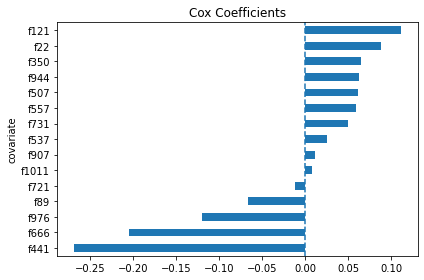

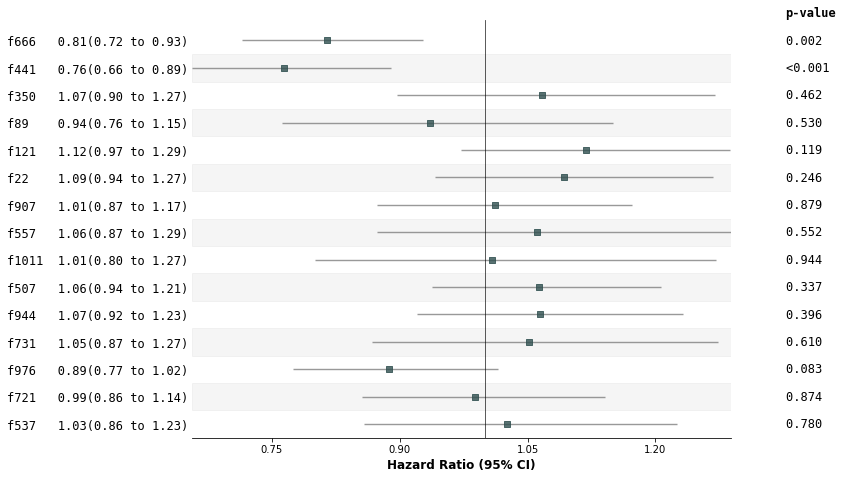

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.349 (95% CI 1.015 - 1.792), p = 0.0392
  G3 vs G1: HR = 1.965 (95% CI 1.503 - 2.570), p = 7.77e-07

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.144 (95% CI 0.898 - 1.458), p = 0.275
  G3 vs G1: HR = 0.494 (95% CI 0.417 - 0.584), p = 1.52e-16


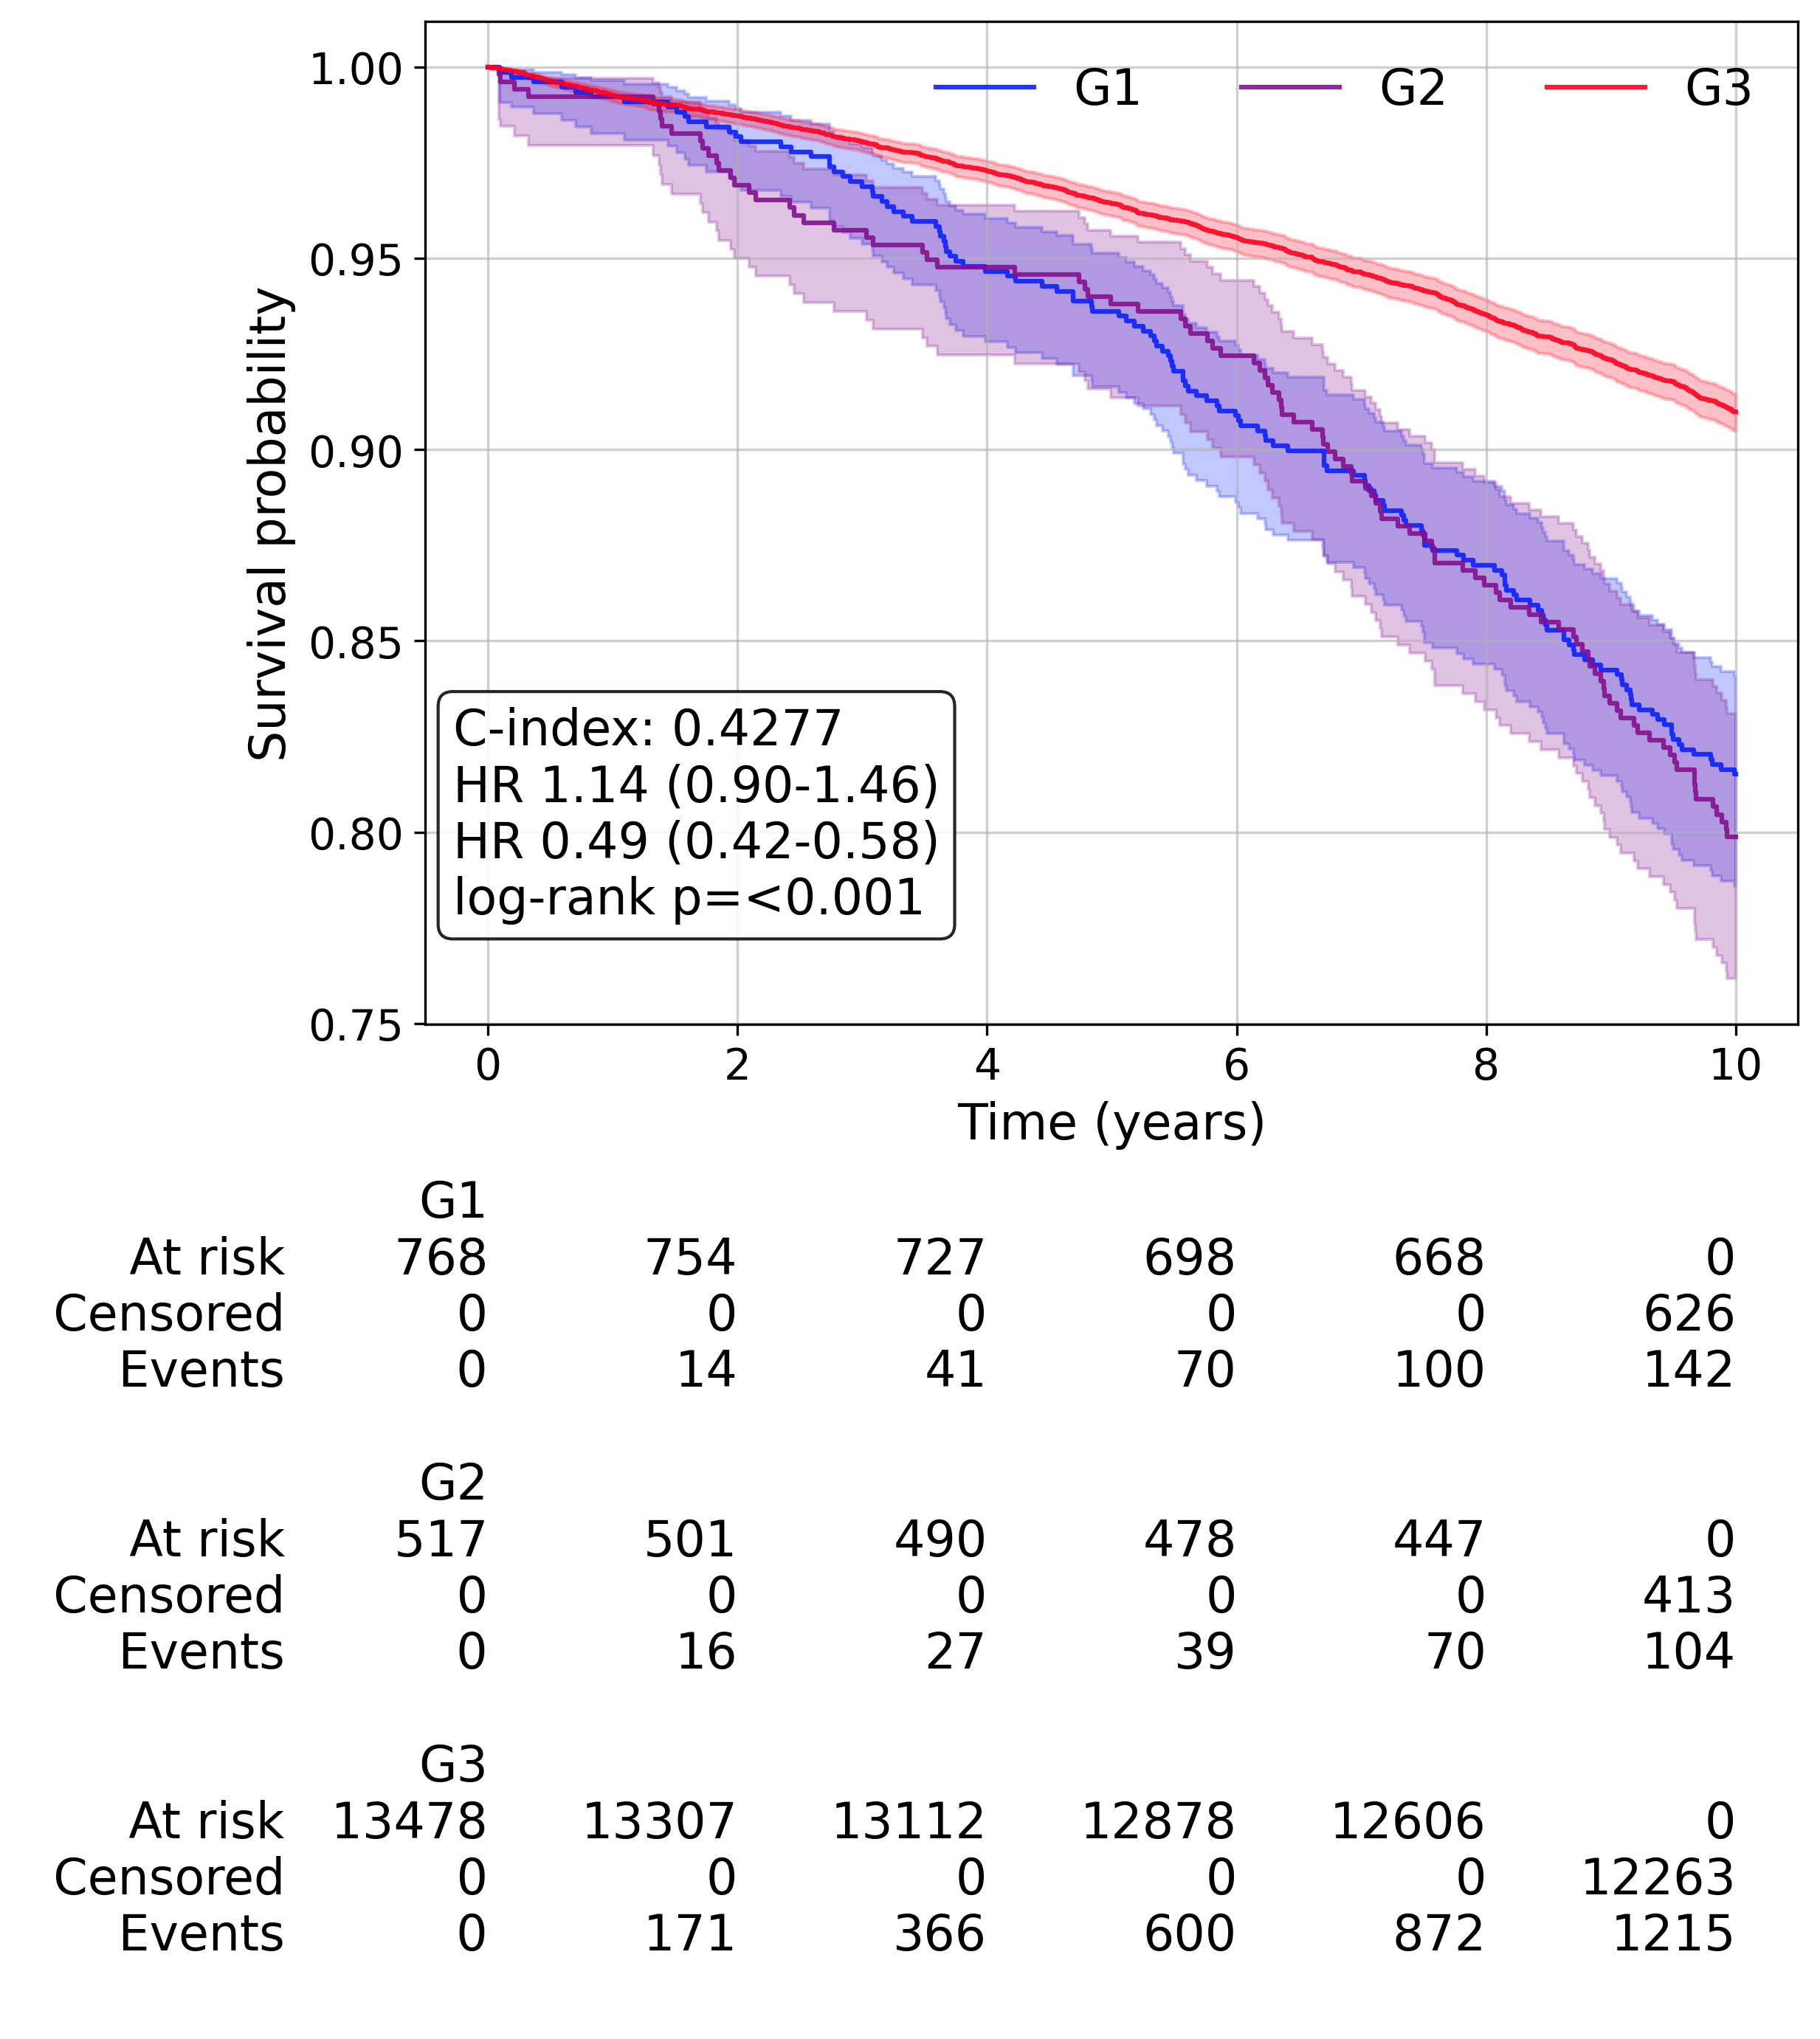

In [70]:
outputs = train_cox_model(train_df = meanpool["D1_cori"],
    test_df =meanpool["D4_cori"],
    selected_features = cori_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test MMACE on D2

 train shape: (14159, 1069)
 test shape: (2435, 1089)


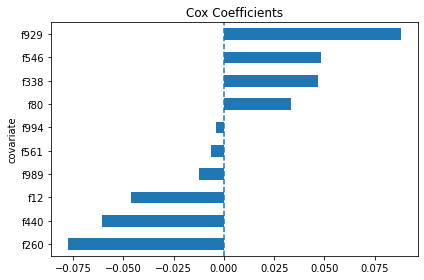

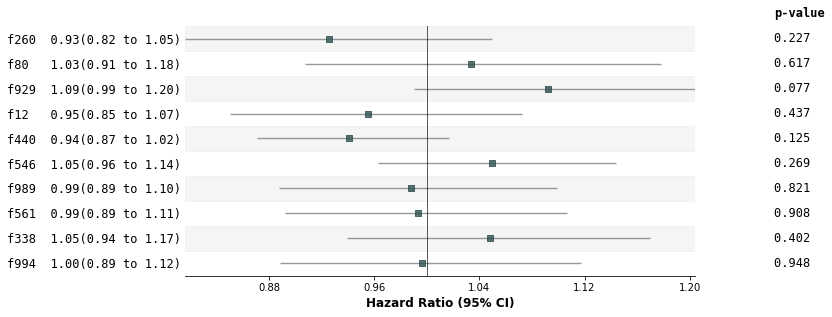

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 0.999 (95% CI 0.875 - 1.141), p = 0.991
  G3 vs G1: HR = 1.790 (95% CI 1.590 - 2.016), p = 7.87e-22

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 0.533 (95% CI 0.000 - 4984.130), p = 0.893
  G3 vs G1: HR = 4.353 (95% CI 0.014 - 1371.811), p = 0.616


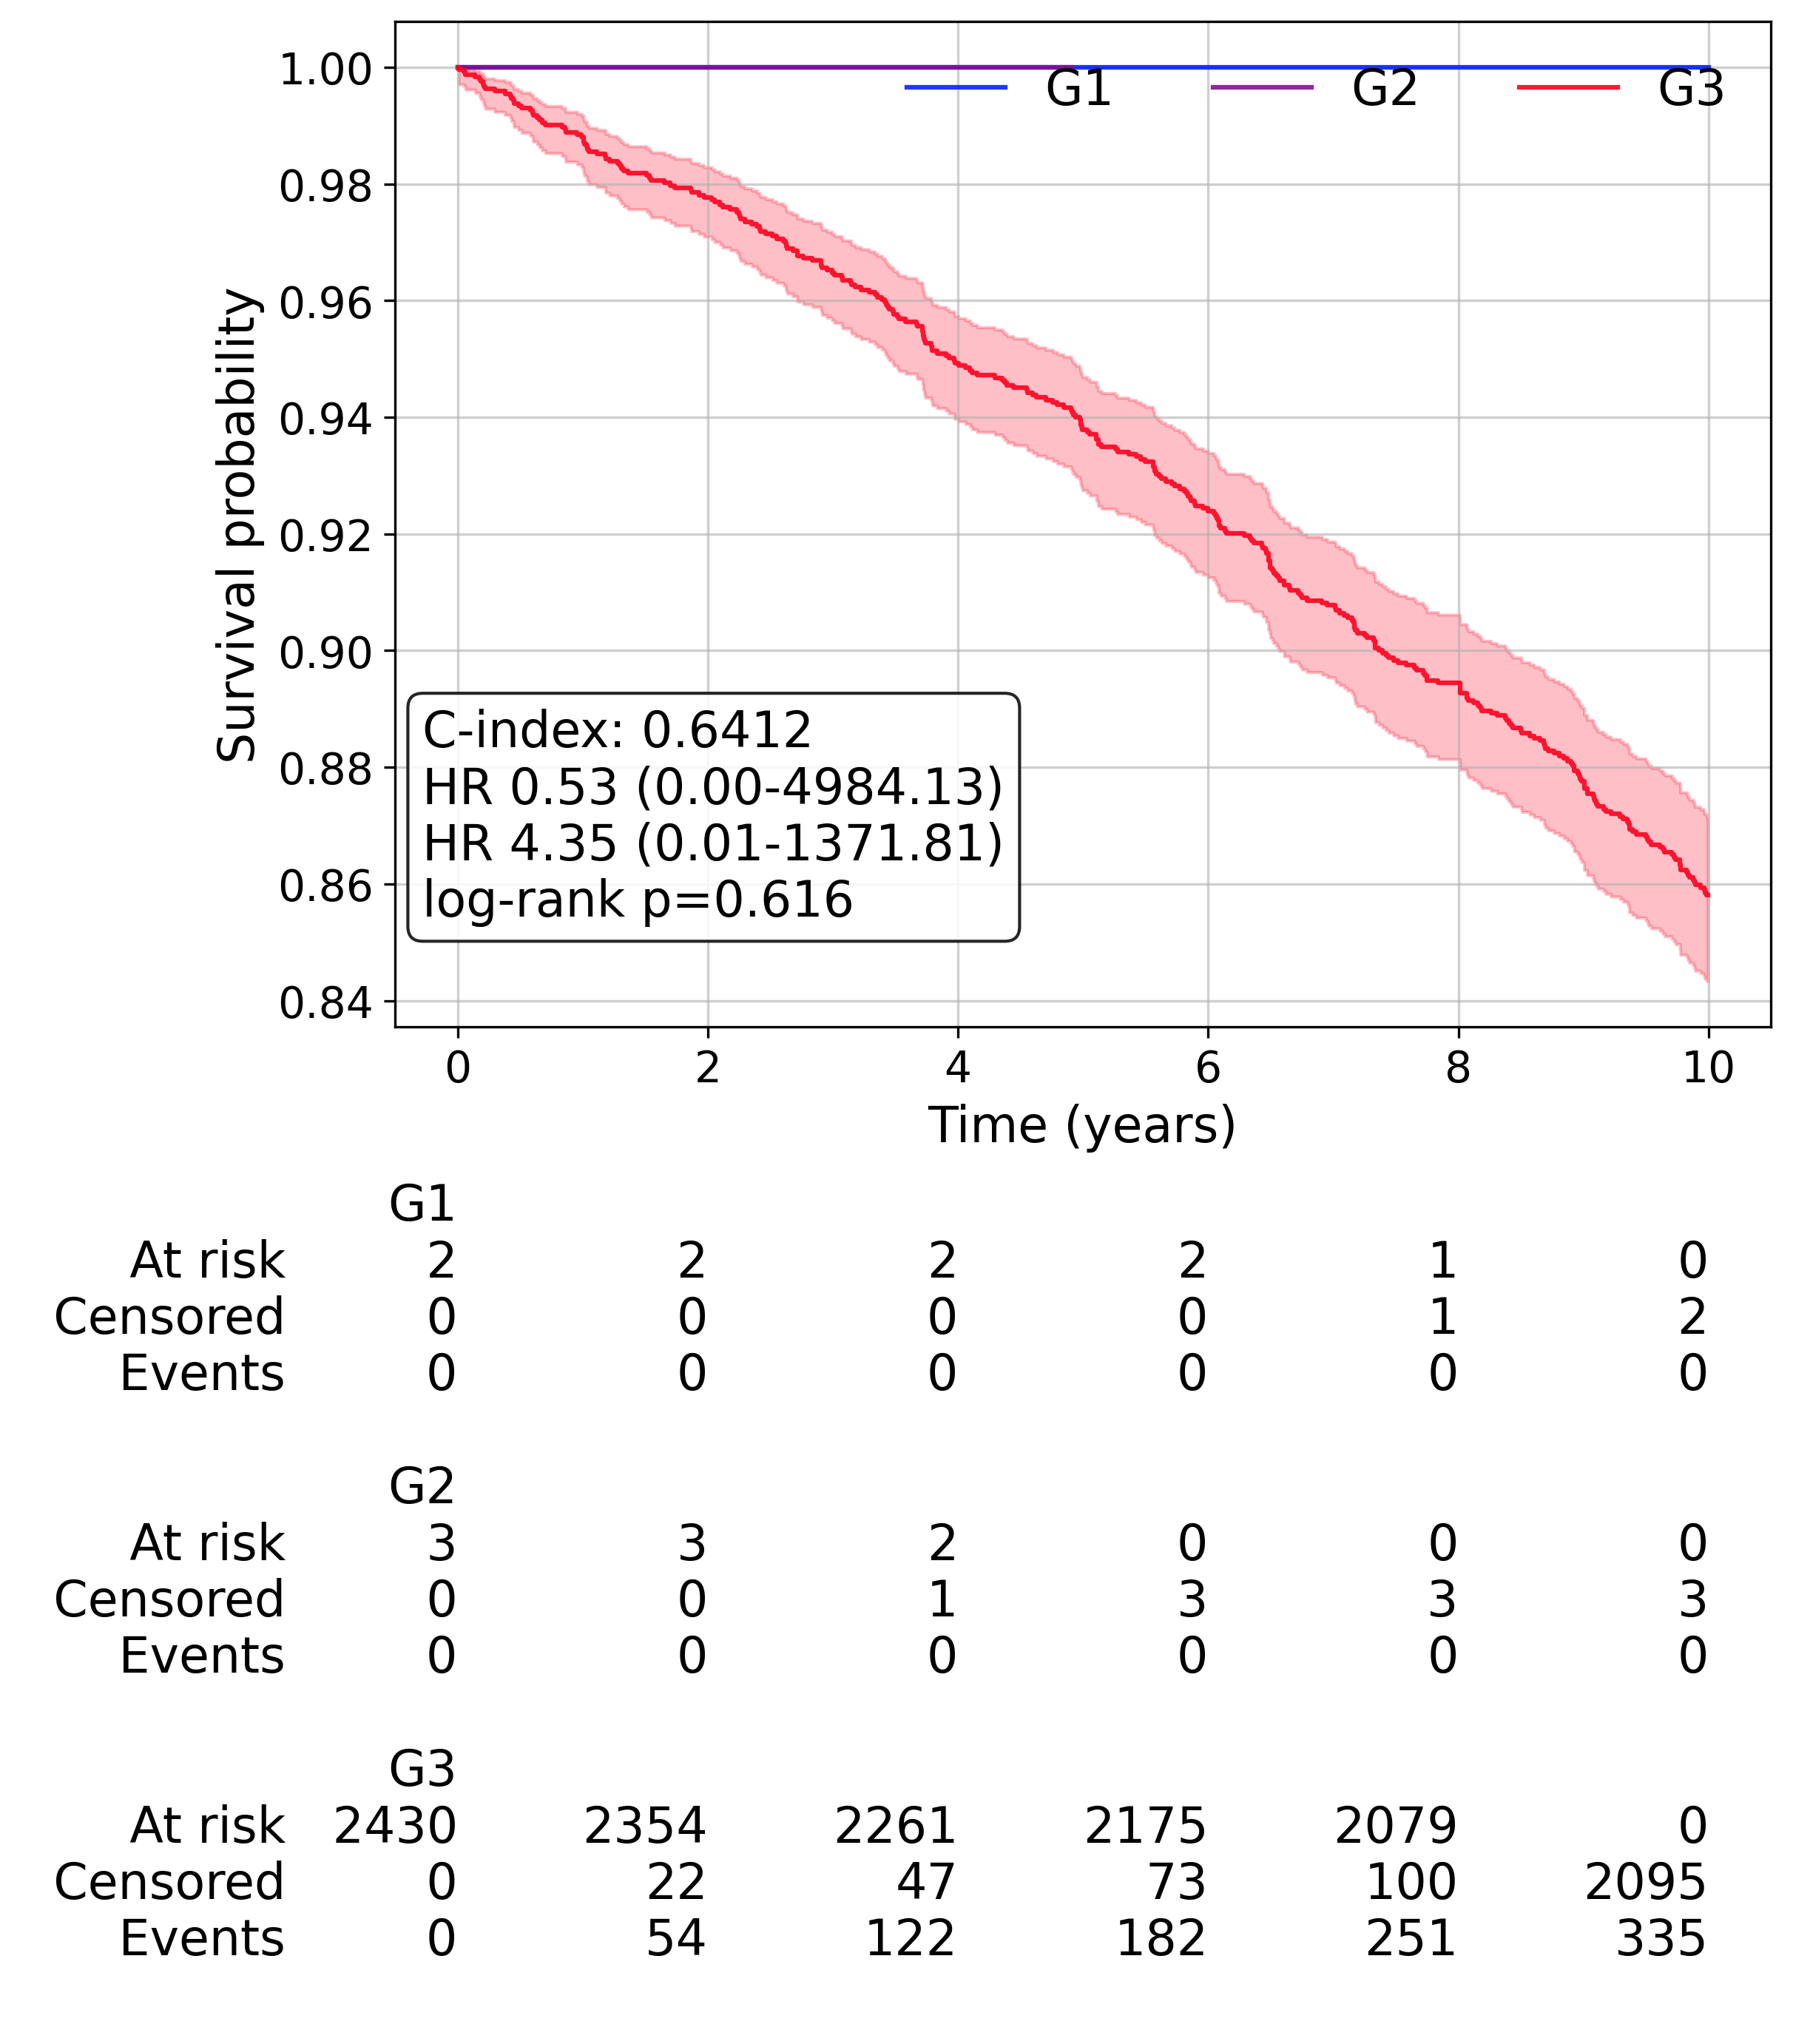

In [71]:

outputs = train_cox_model(train_df = meanpool["D3_mmace"],
    test_df = meanpool["D2_mmace"],
    selected_features =  mmace_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## 13. Treatment-stratified and treatment-adjusted analyses

In [29]:
treatment_rows = []
for value, label in [(0, "No recorded systemic treatment"), (1, "Any recorded systemic treatment")]:
    subset = meanpool["D2_cori"].loc[meanpool["D2_cori"]["any_treatment"] == value]
    if subset["Y_mace"].sum() >= 5:
        treatment_rows.append(performance_row(subset, label, "CORI_z", "CORI_high", 500))
treatment_performance = pd.DataFrame(treatment_rows)
# save_table(treatment_performance, "Table_11A_treatment_stratified_CORI")

adjusted_treatment, _ = adjusted_cox(
    meanpool["D2_cori"], "CORI_z", [*TREATMENT_COLUMNS, *PRIMARY_ADJUSTMENT]
)
# save_table(adjusted_treatment, "Table_11B_treatment_adjusted_CORI")

interaction_rows = []
for treatment_column in [*TREATMENT_COLUMNS, "any_treatment"]:
    summary, _ = adjusted_cox(
        meanpool["D2_cori"], "CORI_z", PRIMARY_ADJUSTMENT,
        interaction_column=treatment_column,
    )
    interaction_term = f"CORI_z_x_{treatment_column}"
    row = summary.loc[summary["term"] == interaction_term].iloc[0].to_dict()
    row["treatment"] = treatment_column
    interaction_rows.append(row)
# save_table(pd.DataFrame(interaction_rows), "Table_11C_treatment_by_CORI_interactions")

KeyError: "['CORI_z'] not in index"

## 14. Center-level performance

In [30]:
center_data = meanpool["D2_cori"].copy()
center_data["reporting_center"] = center_data["center"].replace({"Liverpool": "Liverpool + Swansea", "Swansea": "Liverpool + Swansea"})
center_rows = []
for center, subset in center_data.groupby("reporting_center"):
    if subset["Y_mace"].sum() >= 5:
        center_rows.append(performance_row(subset, center, "CORI_z", "CORI_high", 500))
center_table = pd.DataFrame(center_rows)
save_table(center_table, "Table_07_center_level_CORI_performance")
forest_plot(center_table, "cohort", "HR", "HR_low", "HR_high", "CORI high versus low by center", FIGURE_DIR / "Figure_S_center_forest")

KeyError: "['CORI_z'] not in index"

## 15. Age, sex, treatment, and cancer-site subgroup analyses

In [ ]:
# ============================================================
# Prespecified CORI subgroup associations in held-out D2
# ============================================================

d2_subgroups = meanpool["D2_cori"].copy()

d2_subgroups["age_group"] = np.where(
    d2_subgroups["age"] < 60,
    "Age <60",
    "Age ≥60",
)

d2_subgroups["sex_group"] = np.where(
    d2_subgroups["female"] == 1,
    "Female",
    "Male",
)

d2_subgroups["treatment_group"] = np.where(
    d2_subgroups["any_treatment"] == 1,
    "Recorded treatment",
    "No recorded treatment",
)


# ------------------------------------------------------------
# Age, sex, and recorded-treatment subgroups
# ------------------------------------------------------------

subgroup_tables = [
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="age_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="sex_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="treatment_group",
        minimum_events=15,
        covariates=PRIMARY_ADJUSTMENT,
    ),
]


# ------------------------------------------------------------
# Cancer-site subgroups
# ------------------------------------------------------------

for site in CANCER_SITE_COLUMNS:
    if site not in d2_subgroups.columns:
        continue

    site_data = d2_subgroups.loc[
        d2_subgroups[site]
        .fillna(0)
        .astype(int)
        .eq(1)
    ].copy()

    events = int(site_data["Y_mace"].sum())

    if events < 20:
        continue

    summary, _ = adjusted_cox(
        site_data,
        score_column="CORI_z",
        covariates=PRIMARY_ADJUSTMENT,
        penalizer=0.01,
    )

    score_row = summary.loc[
        summary["term"] == "CORI_z"
    ].iloc[0]

    subgroup_tables.append(
        pd.DataFrame(
            [
                {
                    "subgroup": "cancer_site",
                    "level": site.replace(
                        "_present",
                        "",
                    ),
                    "N": int(score_row["N"]),
                    "events": int(
                        score_row["events"]
                    ),
                    "HR": score_row["HR"],
                    "HR_low": score_row["HR_low"],
                    "HR_high": score_row["HR_high"],
                    "p": score_row["p"],
                    "dropped_constant": (
                        score_row[
                            "dropped_constant"
                        ]
                    ),
                }
            ]
        )
    )


# ------------------------------------------------------------
# Combine and save
# ------------------------------------------------------------

subgroup_tables = [
    table
    for table in subgroup_tables
    if table is not None
    and not table.empty
]

subgroups = pd.concat(
    subgroup_tables,
    ignore_index=True,
)

subgroup_labels = {
    "age_group": "Age",
    "sex_group": "Sex",
    "treatment_group": "Treatment",
    "cancer_site": "Cancer site",
}

subgroups["forest_label"] = (
    subgroups["subgroup"]
    .map(subgroup_labels)
    .fillna(subgroups["subgroup"])
    + ": "
    + subgroups["level"].astype(str)
)

subgroups = (
    subgroups
    .sort_values(
        ["subgroup", "level"]
    )
    .reset_index(drop=True)
)

display(subgroups)

save_table(
    subgroups,
    "Table_12_subgroup_CORI_associations",
)


# ------------------------------------------------------------
# Forest plot
# The keyword names must match src/plots.py exactly.
# ------------------------------------------------------------

forest_plot(
    df=subgroups,
    label="forest_label",
    estimate="HR",
    lower="HR_low",
    upper="HR_high",
    title=(
        "CORI association across "
        "prespecified subgroups"
    ),
    path=(
        FIGURE_DIR
        / "Figure_S_subgroup_forest"
    ),
)